In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [79]:
def load_data(path):
    df = pd.read_csv(path)
    return df

In [80]:
def preprocess_data(df):
    print("Preprocessing")
    df = df.copy()

    #clean column names
    df.columns = df.columns.str.strip().str.replace(" ", "_")

    print("Columns:", df.columns.tolist())

    #Drop customerid
    if 'CustomerID' in df.columns:
        df = df.drop(columns=['CustomerID'])

    #convert all the categorical columns automatically
    df = pd.get_dummies(df, drop_first=True)

    print("After encoding:")
    print(df.dtypes)

    print("Preprocessing done\n")
    return df

In [81]:
def perform_eda(df):
    print("\nDataset Info:")
    print(df.info())

    print("\nStatistical Summary:")
    print(df.describe())

    #Pairplot
    sns.pairplot(df)
    plt.show()

    #Correlation Heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()

In [82]:
def scale_features(df):
    print("Scaling features")
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)
    print("Scaling complete\n")
    return scaled_data, scaler

In [83]:
def find_optimal_clusters(data):
    print("Finding optimal number of clusters")
    inertia = []
    silhouette_scores = []
    K = range(2, 11)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(data, labels))
    #Elbow Method
    plt.figure()
    plt.plot(K, inertia, marker='o')
    plt.title('Elbow Method (Where curve bends is ideal K)')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.show()
    #Silhouette Score
    plt.figure()
    plt.plot(K, silhouette_scores, marker='o')
    plt.title('Silhouette Score ')
    plt.xlabel('Number of clusters')
    plt.ylabel('Score')
    plt.show()
    best_k = K[np.argmax(silhouette_scores)]
    print(f"Best number of clusters based on silhouette score: {best_k}\n")
    return best_k

In [84]:
def train_kmeans(data, k):
    print(f"Training K-Means with {k} clusters...")
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(data)
    print("Model training complete!\n")
    return model, labels

In [85]:
def visualize_clusters(df, labels):
    print("Visualizing clusters")

    df_viz = df.copy()
    df_viz['Cluster'] = labels

    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x='Annual_Income_(k$)',
        y='Spending_Score_(1-100)',
        hue='Cluster',
        data=df_viz
    )
    plt.title('Customer Segments')
    plt.show()

In [86]:
def save_model(model, scaler, filename='kmeans_model.pkl'):
    print("Saving model")
    with open(filename, 'wb') as f:
        pickle.dump({'model': model, 'scaler': scaler}, f)
    print(f"Model saved as {filename}\n")

In [87]:
def run_pipeline(path):
    print("\n Mall Customer Segmentation Pipeline\n")


    # Step 1: Load data
    df = load_data(path)

    # Step 2: Preprocess
    df_clean = preprocess_data(df)

    # Step 3: EDA
    perform_eda(df_clean)

    print(df_clean.head())
    print(df_clean.dtypes)

    print("Checking for non-numeric columns")
    print(df_clean.select_dtypes(include=['object']).columns)

    # Step 4: Scaling
    scaled_data, scaler = scale_features(df_clean)

    # Step 5: Find best K
    best_k = find_optimal_clusters(scaled_data)

    # Step 6: Train model
    model, labels = train_kmeans(scaled_data, best_k)

    # Step 7: Evaluate
    score = silhouette_score(scaled_data, labels)
    print(f"Silhouette Score: {score}\n")

    # Step 8: Visualize clusters
    visualize_clusters(df_clean, labels)

    # Step 9: Save model
    save_model(model, scaler)

    print("Pipeline completed successfully")


 Mall Customer Segmentation Pipeline

Preprocessing
Columns: ['CustomerID', 'Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score_(1-100)']
After encoding:
Age                       int64
Annual_Income_(k$)        int64
Spending_Score_(1-100)    int64
Genre_Male                 bool
dtype: object
Preprocessing done


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual_Income_(k$)      200 non-null    int64
 2   Spending_Score_(1-100)  200 non-null    int64
 3   Genre_Male              200 non-null    bool 
dtypes: bool(1), int64(3)
memory usage: 5.0 KB
None

Statistical Summary:
              Age  Annual_Income_(k$)  Spending_Score_(1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200

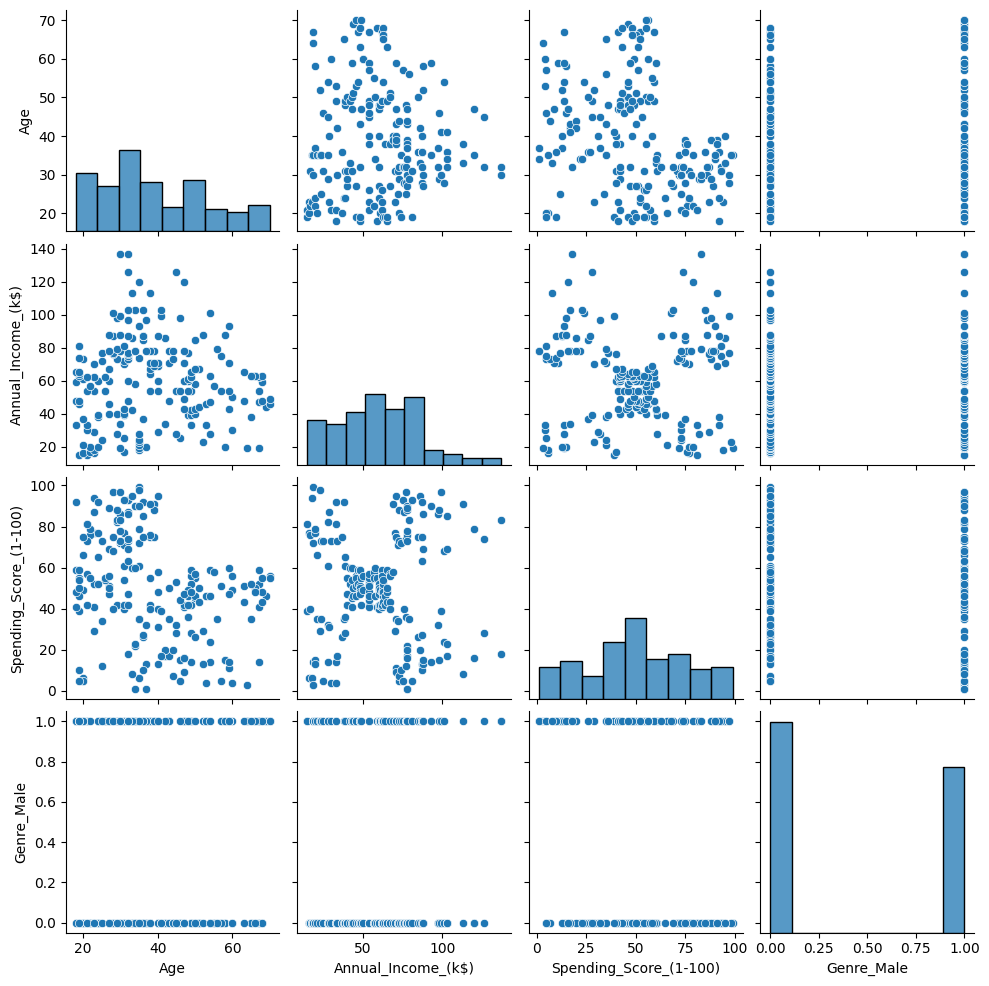

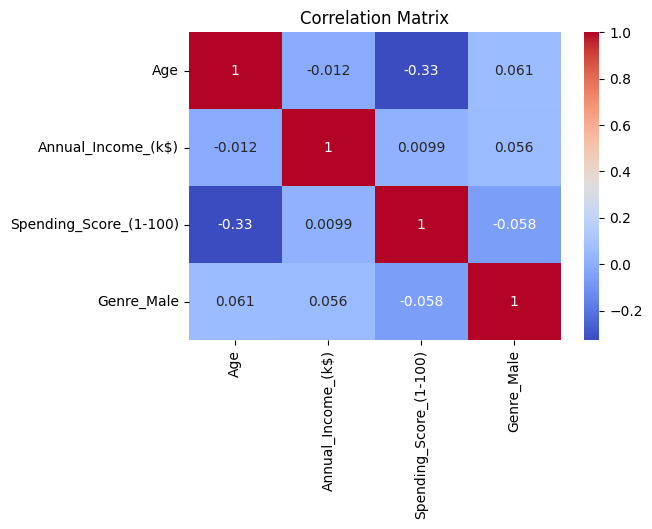

   Age  Annual_Income_(k$)  Spending_Score_(1-100)  Genre_Male
0   19                  15                      39        True
1   21                  15                      81        True
2   20                  16                       6       False
3   23                  16                      77       False
4   31                  17                      40       False
Age                       int64
Annual_Income_(k$)        int64
Spending_Score_(1-100)    int64
Genre_Male                 bool
dtype: object
Checking for non-numeric columns
Index([], dtype='object')
Scaling features
Scaling complete

Finding optimal number of clusters


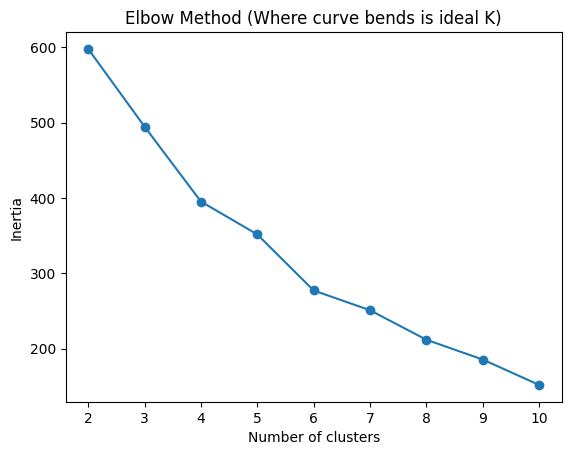

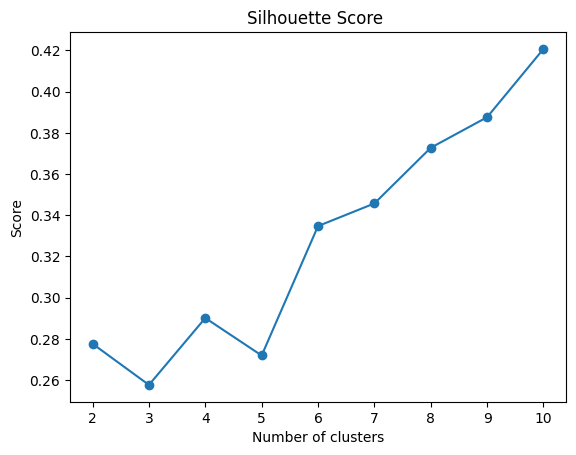

Best number of clusters based on silhouette score: 10

Training K-Means with 10 clusters...
Model training complete!

Silhouette Score: 0.42076374869477745

Visualizing clusters


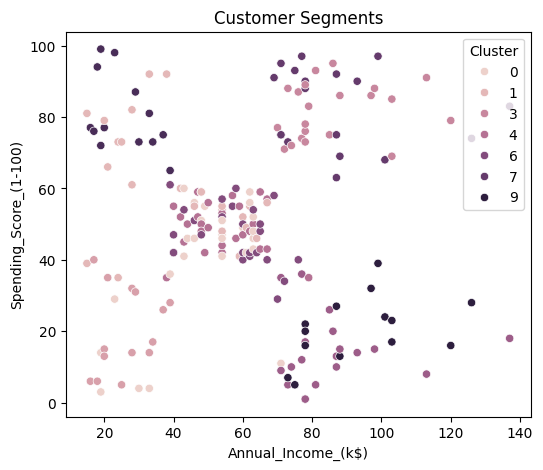

Saving model
Model saved as kmeans_model.pkl

Pipeline completed successfully


In [88]:

if __name__ == '__main__':
    run_pipeline('Mall_Customers.csv')